In [1]:
%cd ..

/home/melanie/PycharmProjects/RedundantPrefrontalHemispheres


In [2]:
import matplotlib.pyplot as plt
plt.style.use("stylefile.mplstyle")
from matplotlib import rcParams

# rcParams['font.family'] = 'serif'
# rcParams['font.serif'] = ['Times New Roman']
# Define colors
colors = {
    "Single": "#333333",
    "Left": "#246EB9",
    "Right": "#8B1E3F",
    'PFC': '#1481BA',
    'PPC': '#533A7B',
    "Ipsilateral": "#1B9E77",
    "Contralateral": "#D95F02",
    "Within": "#2B4162",
    "Across": "#E89D0B",
    'SerialBiasWeak': '#254441',
    'SerialBias': '#43AA8B',\
    'ReactivationWeak': '#7A8A99',
    'Reactivation': '#12719E',
    'Load2': '#CB9090',
    'Load4': '#883041',
    'Load8': '#131614'
}
from matplotlib.colors import LinearSegmentedColormap
left_right_cmap = LinearSegmentedColormap.from_list("LeftRight",\
                                                     [colors['Left'], 'cornflowerblue', "white",\
                                                      'lightcoral', colors['Right']])
ipsi_contra_cmap = LinearSegmentedColormap.from_list("IpsiContra",\
                                                     [colors['Ipsilateral'], "white", colors['Contralateral']])
within_cmap = LinearSegmentedColormap.from_list("Within",\
                                                     ["white", colors['Within']])
across_cmap = LinearSegmentedColormap.from_list("Across",\
                                                     ["white", colors['Across']])
PFCPPC_cmap = LinearSegmentedColormap.from_list("PFCPPC",\
                                                     [colors['PPC'],'thistle', "white",\
                                                      'lightskyblue', colors['PFC']])
PFC_cmap = LinearSegmentedColormap.from_list("PFC",\
                                                     ["white", colors['PFC']])
PPC_cmap = LinearSegmentedColormap.from_list("PPC",\
                                                     ["white", colors['PPC']])


PATH = '../../Desktop/PhD/2_Smith/Figures/Paper/Behavior/Schneegans/'


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cmath import phase
from scipy.stats import circmean, sem
import random
from ast import literal_eval
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib
from filepaths import *
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import ttest_rel, ttest_ind, ttest_1samp, t

def print_stats(a=[], b = [], ttest=ttest_rel, text=''):
    test, pval = ttest(a, b)
    degf = len(a) - 1
    mean_x = np.mean(a - np.array(b))
    se = stats.sem(a - np.array(b))  # standard error of the mean
    ci_low, ci_high = t.interval(0.95, degf, loc=mean_x, scale=se)
    print(text+', '+str(ttest)+': t('+str(degf)+') = '+str(np.round(test, 2))+', p = '+"{:.2e}".format(pval)+\
         ", mean = "+str(np.round(mean_x, 2))+\
         ", 95% CI ["+str(np.round(ci_low,2))+","+str(np.round(ci_high, 2))+"]")
    return

def len2(x):
	if type(x) is not type([]):
		if type(x) is not type(np.array([])):
			return -1
	return len(x)

def phase2(x):
	if not np.isnan(x):
		return phase(x)
	return np.nan

def circdist(angles1,angles2):
    if len2(angles2) < 0:
        if len2(angles1) > 0:
            angles2 = [angles2]*len(angles1)
        else:
            angles2 = [angles2]
            angles1 = [angles1]
        if len2(angles1) < 0:
            angles1 = [angles1]*len(angles2)
    return np.array(list(map(lambda a1,a2: phase2(np.exp(1j*a1)/np.exp(1j*a2)), angles1,angles2)))

def sig_bar(sigs,axis,y,ax,color):
	w=np.diff(axis)[0]
	for s in sigs:
		beg =axis[s]-w/2
		end = axis[s]+w/2
		ax.fill_between([beg,end],[y[0],y[0]],[y[1],y[1]],color=color)
        
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array-value)).argmin()
    return idx

def normgauss(xxx,sigma):
    gauss = (1/(sigma*np.sqrt(2*np.pi)) *np.exp(-(xxx-0)**2 / (2*sigma**2)))
    return gauss/gauss.max()

def normgrad(xxx):
    return np.gradient(xxx)/np.gradient(xxx).max()

def dog1(sigma,x):
    xxx     = np.arange(-2*np.pi, 2*np.pi, .0001) 
    dog_1st = normgrad(normgauss(xxx,sigma))
    return np.array(list(map(lambda x: dog_1st[find_nearest(xxx,x)], x)))

def dog1_scalar(sigma, x):
    gauss = np.exp(-x**2 / (2 * sigma**2))  # peak = 1
    grad = -x / sigma**2 * gauss
    norm_factor = (1 / sigma) * np.exp(-0.5)
    return grad / norm_factor

def dog3(sigma,x):
    xxx     = np.arange(-2*np.pi, 2*np.pi, .0001) 
    dog_3rd = normgrad(normgrad(normgrad(normgauss(xxx,sigma))))
    return np.array(list(map(lambda x: dog_3rd[find_nearest(xxx,x)], x)))

def mov_avg(rel_loc, err, w1, w2, folded):  
    m_err=[]
    std_err=[]
    count=[]
    cis=[]
    x = np.arange(-np.pi,np.pi,w1)
    if folded:
        err = np.array([np.sign(rel_loc[i])*err[i] if np.sign(rel_loc[i])!=0 else err[i] for i in range(len(err))])
        rel_loc = np.abs(rel_loc)
        x = np.arange(0,np.pi,w1)
    for i,t in enumerate(x):
        idx=abs(circdist(rel_loc,t)) <= w2/2
        m_err.append(np.nanmean(err[idx]))
        std_err.append(sem(err[idx], nan_policy='omit'))
           
    return (x), np.array(m_err),np.array(std_err)


# Load Data from Schneegans et al. 

In [4]:
DATA_SMITH

'./Results/'

In [5]:
df1 = pd.read_csv(DATA_SMITH + "Schneegans/data1/dataExp1.csv")

df1 = df1.loc[df1.SetSize > 1].copy().reset_index(drop=True)
print(len(df1))

df1['response'] = df1.ResponseDirection
df1['dataset'] = 1# later understand which dataset is which
df1['error'] = circdist(df1.response.values, df1.ItemLocations_1.values)
df1 = df1.loc[np.abs(df1.error) < np.deg2rad(50)].copy().reset_index(drop=True)
print(len(df1))


# get relative distances
df1['rel_loc2'] = circdist(df1.ItemLocations_2.values, df1.ItemLocations_1.values)
df1['rel_loc3'] = circdist(df1.ItemLocations_3.values, df1.ItemLocations_1.values)
df1['rel_loc4'] = circdist(df1.ItemLocations_4.values, df1.ItemLocations_1.values)

print('Excluded '+str(2560-2463)+' out of 2560 trials')

2560
2463
Excluded 97 out of 2560 trials


# Load dataset 2

In [7]:
from scipy.io import loadmat

mat_file = loadmat(DATA_SMITH + "Schneegans/data2/all_data_colour.mat")

# Columns you want to include (exclude meta keys)
valid_keys = [k for k in mat_file.keys() if not k.startswith("__")]

data = {}

for key in valid_keys:
    arr = mat_file[key]

    # MATLAB arrays often load as Nx1 or 1xN — flatten to 1D
    if isinstance(arr, np.ndarray):
        arr = arr.squeeze()     # remove singleton dims
    try:
        arr.shape[1]
        arr = [[arr[i]] for i in range(len(arr))]
    except:
        arr = arr
    data[key] = arr

# Build DataFrame
df2 = pd.DataFrame(data)
df2 = df2.loc[df2.n_items > 1].reset_index(drop=True)
print(len(df2))

# add response
df2['response'] = [np.arctan2(df2.response_pos[i][0][1], df2.response_pos[i][0][0])\
                  for i in df2.index]
df2['Subject'] = df2.subject + np.max(df1.Subject)
df2['SetSize'] = df2.n_items
df2['dataset'] = 2
df2['DelayDuration'] = 1000
# compute angle and separate targets
for targ_id in range(df2.n_items.max()): # for each of the 8 potential targets
    df2['ItemLocations_'+str(targ_id+1)] = [np.arctan2(targ[0][1][targ_id],\
                                               targ[0][0][targ_id])\
                                           for targ in df2['item_pos']]
df2['error'] = circdist(df2.response.values, df2.ItemLocations_1.values)

df2 = df2.loc[np.abs(df2.error) < np.deg2rad(50)].copy().reset_index(drop=True)
print(len(df2))

# relative distance to all distractors
for targ_id in range(1, df2.n_items.max()): # for each of the 8 potential targets
    df2['rel_loc'+str(targ_id+1)] = circdist(df2['ItemLocations_'+str(targ_id+1)].values, df2.ItemLocations_1.values)
    
print('Excluded '+str(2635-2479)+' out of 2635 trials')

2635
2479
Excluded 156 out of 2635 trials


# Combine data frames

In [8]:
df = pd.concat([df1, df2]).reset_index()


# Fit distraction hyperparameter

In [9]:
print('Fit sigmas:\nData 1 = 0.8\nData 2 = 1.1\nBoth = 1.1')
sigma = {1: 0.8, 2: 1.1}
sigma = {1: {2:1.4, 4:0.8}, 2: {2: 1.0, 4: 0.7, 8:1.2}}
         
df['sigma'] = [sigma[df.loc[i, 'dataset']][df.loc[i, 'SetSize']] for i in df.index]#[sigma[i] for i in df.dataset]

Fit sigmas:
Data 1 = 0.8
Data 2 = 1.1
Both = 1.1


#### Data 1

In [10]:
# ######### RUN MODEL COMPARISON #################
# # we ignore setsize = 8 (only some participants have it)
# df_helper = df1.loc[df.SetSize==4].copy().reset_index()
# sfit = []

# sigma_range = np.arange(0.1, 2, 0.1)
# colorsLoad = ['lightsalmon', 'darkred', 'k']
# f, ax = plt.subplots(figsize=(1.8,2))
# df_load = df_helper
# for s in sigma_range:
#     # get the maximum distractor attraction for the specified sigma
#     df_load['expectedAttraction2'] = dog1(s, df_load['rel_loc2'].values)
#     df_load['expectedAttraction3'] = dog1(s, df_load['rel_loc3'].values)
#     df_load['expectedAttraction4'] = dog1(s, df_load['rel_loc4'].values)

#     # compute the strongest distractor 
#     strongest_distr = np.nanargmax([np.abs(df_load['expectedAttraction2']),\
#                         np.abs(df_load['expectedAttraction3']), np.abs(df_load['expectedAttraction4'])], axis=0) + 2
#     # distance to strongest distractor
#     df_load['rel_loc'] = [df_load['rel_loc'+str(i)][iidx] for iidx, i in enumerate(strongest_distr)]

#     # get model BIC
#     df_load['DoG'] = -dog1(s, df_load.rel_loc)
#     M_all = smf.ols('error ~ DoG', data=df_load).fit()
#     sfit.append(M_all.bic)

# ax.plot(sigma_range, sfit, color='darkblue', label=load)
# ax.axvline(sigma_range[np.argmin(sfit)], dashes=[3,3], lw=0.5, color='k')
# ax.set_xlabel('$\sigma$')
# ax.set_ylabel('BIC')
# plt.tight_layout()
# plt.savefig(PATH + 'SigmaOptimize_df1_Setsize4.svg', dpi=300)
# print('$\sigma_{opt}$ = '+str(sigma_range[np.argmin(sfit)]))

### Data 2

In [11]:
# ######### RUN MODEL COMPARISON #################
# # we ignore setsize = 8 (only some participants have it)
# df_helper = df2.loc[df.SetSize==8].copy().reset_index()
# sfit = []

# sigma_range = np.arange(0.1, 2, 0.1)
# colorsLoad = ['lightsalmon', 'darkred', 'k']
# f, ax = plt.subplots(figsize=(1.8,2))
# df_load = df_helper
# for s in sigma_range:
#     # get the maximum distractor attraction for the specified sigma
#     df_load['expectedAttraction2'] = dog1(s, df_load['rel_loc2'].values)
#     df_load['expectedAttraction3'] = dog1(s, df_load['rel_loc3'].values)
#     df_load['expectedAttraction4'] = dog1(s, df_load['rel_loc4'].values)
#     df_load['expectedAttraction5'] = dog1(s, df_load['rel_loc5'].values)
#     df_load['expectedAttraction6'] = dog1(s, df_load['rel_loc6'].values)
#     df_load['expectedAttraction7'] = dog1(s, df_load['rel_loc7'].values)
#     df_load['expectedAttraction8'] = dog1(s, df_load['rel_loc8'].values)

#     # compute the strongest distractor 
#     strongest_distr = np.nanargmax([np.abs(df_load['expectedAttraction2']),\
#                         np.abs(df_load['expectedAttraction3']), np.abs(df_load['expectedAttraction4']),\
#                         np.abs(df_load['expectedAttraction5']), np.abs(df_load['expectedAttraction6']),\
#                                  np.abs(df_load['expectedAttraction7']), np.abs(df_load['expectedAttraction8'])], axis=0) + 2
#     # distance to strongest distractor
#     df_load['rel_loc'] = [df_load['rel_loc'+str(i)][iidx] for iidx, i in enumerate(strongest_distr)]

#     # get model BIC
#     df_load['DoG'] = -dog1(s, df_load.rel_loc)
#     M_all = smf.ols('error ~ DoG', data=df_load).fit()
#     sfit.append(M_all.bic)

# ax.plot(sigma_range, sfit, color='darkgreen', label=load)
# ax.axvline(sigma_range[np.argmin(sfit)], dashes=[3,3], lw=0.5, color='k')
# ax.set_xlabel('$\sigma$')
# ax.set_ylabel('BIC')
# plt.tight_layout()
# plt.savefig(PATH + 'SigmaOptimize_data2_setsize4.svg', dpi=300)
# print('$\sigma_{opt}$ = '+str(sigma_range[np.argmin(sfit)]))

## compute relative distance to the closest distractor (with optimized $\sigma$)

In [12]:
df['expectedAttraction2'] = [-dog1_scalar(df.sigma[i], df.loc[i,'rel_loc2']) for i in df.index]
df['expectedAttraction3'] = [-dog1_scalar(df.sigma[i], df.loc[i,'rel_loc3']) for i in df.index]
df['expectedAttraction4'] = [-dog1_scalar(df.sigma[i], df.loc[i,'rel_loc4']) for i in df.index]
df['expectedAttraction5'] = [-dog1_scalar(df.sigma[i], df.loc[i,'rel_loc5']) for i in df.index]
df['expectedAttraction6'] = [-dog1_scalar(df.sigma[i], df.loc[i,'rel_loc6']) for i in df.index]
df['expectedAttraction7'] = [-dog1_scalar(df.sigma[i], df.loc[i,'rel_loc7']) for i in df.index]
df['expectedAttraction8'] = [-dog1_scalar(df.sigma[i], df.loc[i,'rel_loc8']) for i in df.index]

df['expectedAttraction_total'] = np.nansum([df['expectedAttraction2'], df['expectedAttraction3'],\
                                         df['expectedAttraction4'],df['expectedAttraction5'],\
                                        df['expectedAttraction6'], df['expectedAttraction7'],\
                                         df['expectedAttraction8']], axis=0)
# compute the strongest distractor 
strongest_distr = np.nanargmax([np.abs(df['expectedAttraction2']),\
                    np.abs(df['expectedAttraction3']), np.abs(df['expectedAttraction4']),\
                               np.abs(df['expectedAttraction5']), np.abs(df['expectedAttraction6']),\
                               np.abs(df['expectedAttraction7']), np.abs(df['expectedAttraction8'])], axis=0) + 2

#,\
#                     np.abs(df['expectedAttraction5']), np.abs(df['expectedAttraction6']),\
#                              np.abs(df['expectedAttraction7']), np.abs(df['expectedAttraction8'])

# distance to strongest distractor
df['strongestDistr_ID'] = strongest_distr
df['rel_loc'] = [df['rel_loc'+str(i)][iidx] for iidx, i in enumerate(strongest_distr)]
df['DoG'] = [df['expectedAttraction'+str(i)][iidx] for iidx, i in enumerate(strongest_distr)]
df1['rel_loc'] = df.loc[df.dataset==1].rel_loc.values
df2['rel_loc'] = df.loc[df.dataset==2].rel_loc.values

# Plot each data set

/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/ipykernel_launcher.py:96: RuntimeWarning: Mean of empty slice
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


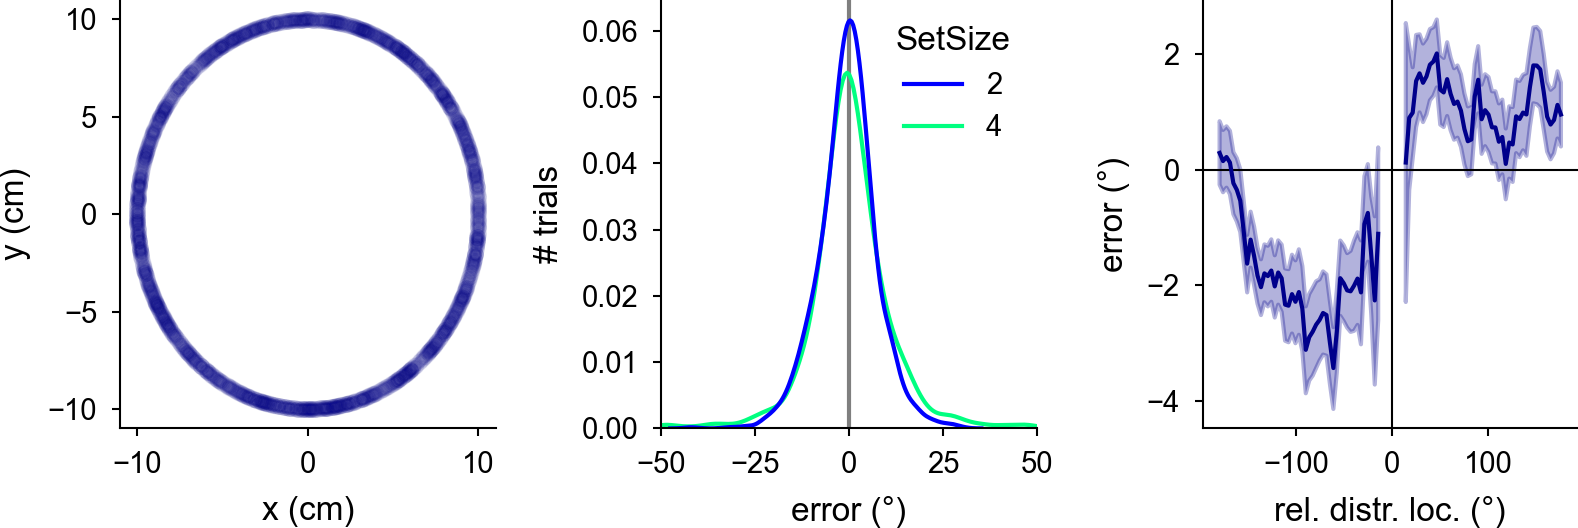

In [13]:
w1=np.pi/50
w2=np.pi/5
folded=False

f, ax = plt.subplots(1,3, figsize=(5.5,2))
plt.subplots_adjust(wspace=0.6)
ax[0].scatter(np.sin(df1.ItemLocations_1)*10, np.cos(df1.ItemLocations_1)*10, alpha=0.03, color='darkblue')
ax[0].set_xlabel('x (cm)')
ax[0].set_ylabel('y (cm)')

df1['error_deg'] = np.rad2deg(df1.error)
ax[1].axvline(0, color='k', alpha=0.5)
sns.kdeplot(data = df1, x = 'error_deg', hue = 'SetSize',ax=ax[1], palette='winter', common_norm=False);
ax[1].set_xlabel('error (°)')
ax[1].set_xlim([-50, 50])
ax[1].set_ylabel('# trials')

dfload2 = df1.loc[df1.SetSize==2]
xx, m_err, std_err = mov_avg(dfload2.rel_loc.values, dfload2.error.values, w1, w2, folded)
ax[2].axhline(0, color='k', lw=0.5)
ax[2].axvline(0, color='k', lw=0.5)
ax[2].plot(np.rad2deg(xx), np.rad2deg(m_err), color='darkblue')
ax[2].fill_between(np.rad2deg(xx), np.rad2deg(m_err-std_err), np.rad2deg(m_err+std_err), alpha=0.3, color='darkblue')
ax[2].set_xlabel('rel. distr. loc. (°)')
ax[2].set_ylabel('error (°)')
plt.tight_layout()
plt.savefig(PATH+'Data1.svg')

### data 2

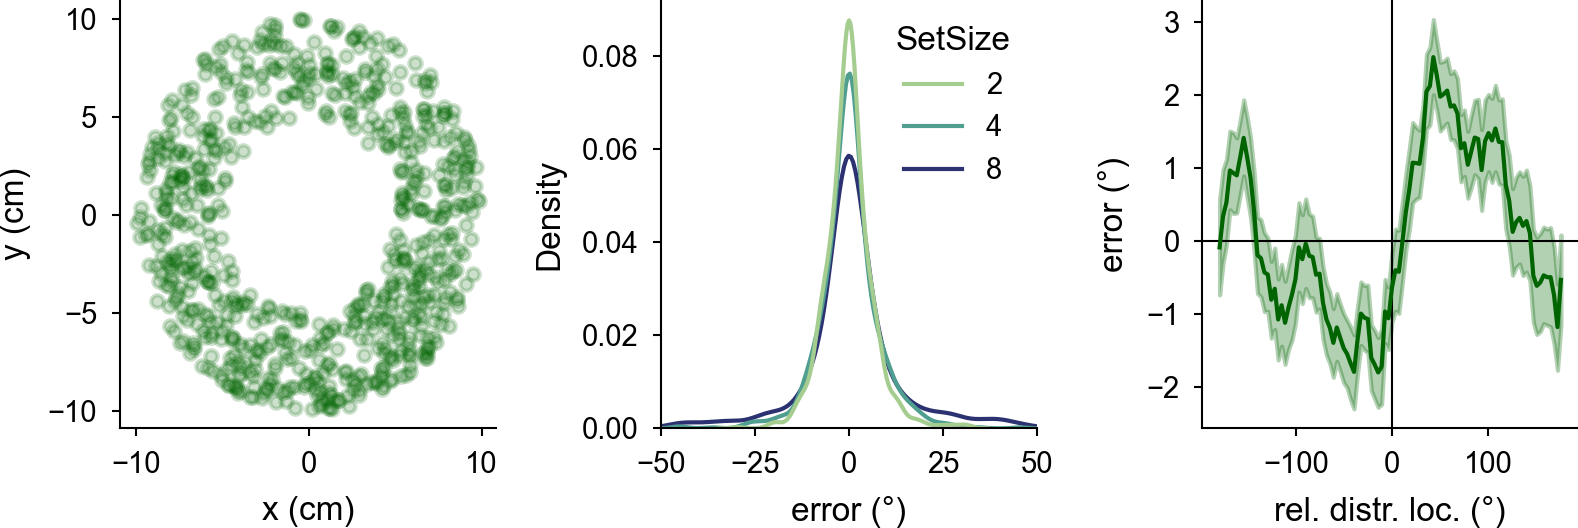

In [14]:
f, ax = plt.subplots(1,3, figsize=(5.5,2))
ax[0].scatter([targ[0][0][targ_id] for targ in df2['item_pos']],\
           [targ[0][1][targ_id] for targ in df2['item_pos']], color='darkgreen', alpha=0.2)
ax[0].set_xlabel('x (cm)')
ax[0].set_ylabel('y (cm)')

df2['error_deg'] = np.rad2deg(df2.error)
sns.kdeplot(data = df2, x = 'error_deg', hue = 'SetSize',ax=ax[1], palette='crest', common_norm=False);
ax[1].set_xlabel('error (°)')
ax[1].set_xlim([-50, 50])
# distractor attraction data 2

dfload2 = df2#.loc[df2.SetSize==8]
xx, m_err, std_err = mov_avg(dfload2.rel_loc.values, dfload2.error.values, w1, w2, folded)
ax[2].axhline(0, color='k', lw=0.5)
ax[2].axvline(0, color='k', lw=0.5)
ax[2].plot(np.rad2deg(xx), np.rad2deg(m_err), color='darkgreen')
ax[2].fill_between(np.rad2deg(xx), np.rad2deg(m_err-std_err), np.rad2deg(m_err+std_err), alpha=0.3, color='darkgreen')
ax[2].set_xlabel('rel. distr. loc. (°)')
ax[2].set_ylabel('error (°)')
plt.tight_layout()
plt.savefig(PATH+'Data2.svg')

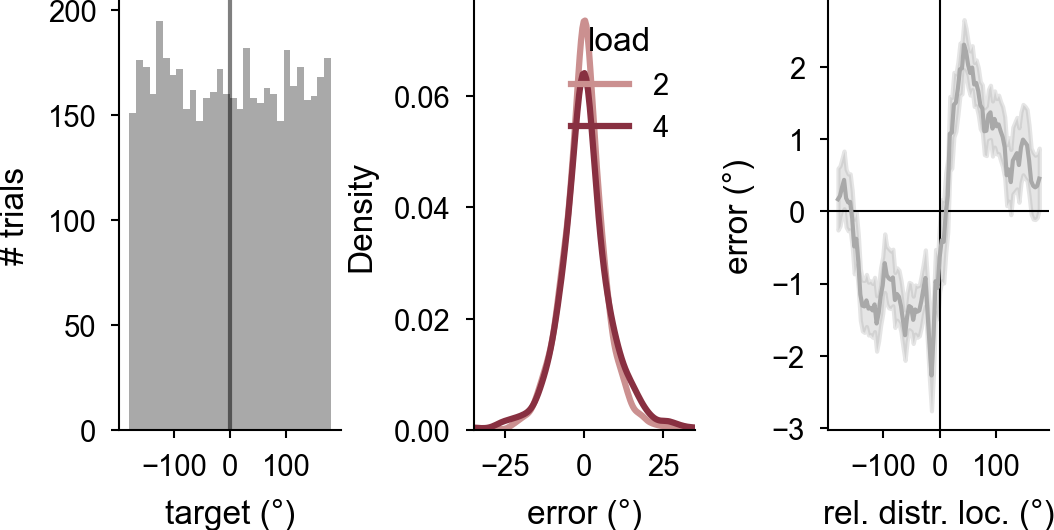

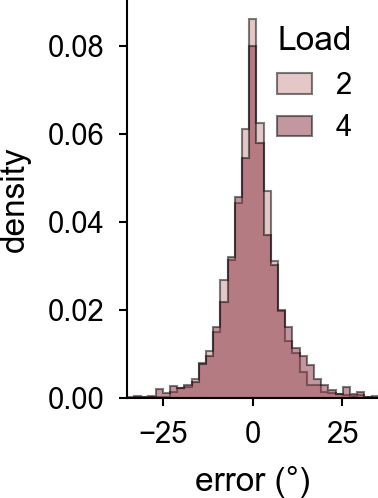

In [15]:
folded=False
f, ax = plt.subplots(1,3, figsize=(4,1.9))
plt.subplots_adjust(wspace=0.6)
ax[0].axvline(0, color='k', alpha=0.5)
ax[0].hist(np.rad2deg(df.ItemLocations_1), bins=30, color='darkgrey')
ax[0].set_xlabel('target (°)')
ax[0].set_ylabel('# trials')

df['error_deg'] = np.rad2deg(df.error)
sns.kdeplot(df.loc[df.SetSize==2].error_deg, ax=ax[1], common_norm=False, color=colors['Load2'],\
            lw=1.5, label='2')#, palette='cividis');
sns.kdeplot(df.loc[df.SetSize==4].error_deg, ax=ax[1], common_norm=False, color=colors['Load4'],\
            lw=1.5, label='4')#, palette='cividis');
ax[1].set_xlim([-35, 35])
ax[1].set_xlabel('error (°)')
ax[1].legend(title="load", frameon=False)
# distractor attraction data 2

xx, m_err, std_err = mov_avg(df.rel_loc.values, df.error.values, w1, w2, folded)
ax[2].axhline(0, color='k', lw=0.5)
ax[2].axvline(0, color='k', lw=0.5)
ax[2].plot(np.rad2deg(xx), np.rad2deg(m_err), color='darkgrey')
ax[2].fill_between(np.rad2deg(xx), np.rad2deg(m_err-std_err), np.rad2deg(m_err+std_err), alpha=0.3, color='darkgrey')
ax[2].set_xlabel('rel. distr. loc. (°)')
ax[2].set_ylabel('error (°)')


f, ax = plt.subplots(figsize=(1.5,1.9))
binspace = np.linspace(-180, 180, 180)
plt.hist(df.loc[df.SetSize==2].error_deg, bins=binspace, color= colors['Load2'],\
         density=True, label='2', alpha=0.5, histtype='stepfilled',linewidth=0.5,
    edgecolor='k',)
plt.hist(df.loc[df.SetSize==4].error_deg, bins=binspace, color= colors['Load4'],linewidth=0.5,\
         density=True, label='4', alpha=0.5, edgecolor='k', histtype='stepfilled')
ax.set_xlabel('error (°)')
ax.set_ylabel('density')
ax.legend(title='Load', handlelength=1.2)
ax.set_xlim([-35, 35])
plt.tight_layout()
plt.savefig(PATH+'Capacity.svg', dpi=300)


Text(0, 0.5, '# trials')

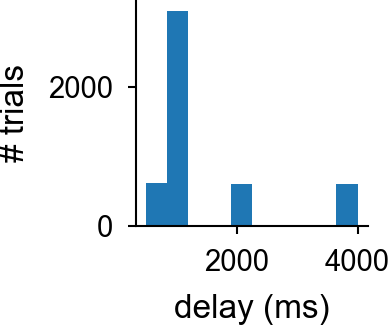

In [16]:
plt.figure(figsize=(1,1))
plt.hist(df.DelayDuration)
plt.xlabel('delay (ms)')
plt.ylabel('# trials')

### remove systematic biases

In [14]:
# from numpy.polynomial.polynomial import Polynomial

# fit_deg = 30

# # Fit a polynomial to the data
# y_corrected = np.zeros((len(df)))
# xy, biasfit = np.linspace(-np.pi, np.pi, 1000, endpoint=False), []
# y_sessioncorrected = np.zeros((len(df)))

# for subj in df.Subject.unique():
#     df_subj = df.loc[df.Subject==subj].copy()
        
#     # behavior
#     poly_fit = Polynomial.fit(df_subj.ItemLocations_1.values, df_subj.error.values, deg=fit_deg)  # fit polynomial
#     systematicBias = poly_fit(df_subj.ItemLocations_1.values)  # Evaluate the trend
#     y_corrected[df_subj.index] = circdist(df_subj.error.values, systematicBias)  # Subtract the trend
#     biasfit.append(poly_fit(xy))  

# df['error_corrected'] = list(y_corrected)


# # plot corrected error
# f, ax = plt.subplots(figsize=(2,2))
# #plt.scatter(np.rad2deg(df.ItemLocations_1), np.rad2deg(df.error), alpha=0.1)
# xx, m_err, std_err = mov_avg(df.ItemLocations_1.values, df.error.values, w1, w2, False)
# plt.plot(np.rad2deg(xx), np.rad2deg(m_err), color='k', label='original')
# xx, m_err, std_err = mov_avg(df.ItemLocations_1.values, df.error_corrected.values, w1, w2, False)
# plt.plot(np.rad2deg(xx), np.rad2deg(m_err), color='darkred', label='corrected')
# plt.xlabel('target (°)')
# plt.ylabel('error (°)')
# plt.legend()
# plt.show()

### define hemifields

In [17]:
num_subj = len(df.Subject.unique())

# define hemifield for each item
# target hemifield
df['hemi'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t) else 'nan' for t in df.ItemLocations_1.values]
# distr hemi
df['hemiD2'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t)\
                else 'nan' for t in df.ItemLocations_2.values]
df['hemiD3'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t)\
                else 'nan' for t in df.ItemLocations_3.values]
df['hemiD4'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t)\
                else 'nan' for t in df.ItemLocations_4.values]
df['hemiD5'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t)\
                else 'nan' for t in df.ItemLocations_5.values]
df['hemiD6'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t)\
                else 'nan' for t in df.ItemLocations_6.values]
df['hemiD7'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t)\
                else 'nan' for t in df.ItemLocations_7.values]
df['hemiD8'] = ['L' if (t > -np.pi/2) & (t < np.pi/2) else 'R' if not np.isnan(t)\
                else 'nan' for t in df.ItemLocations_8.values]
# get hemifield of closest distractor
df['hemiD'] = [df['hemiD'+str(i)][iidx] for iidx, i in enumerate(strongest_distr)]
df['withinAcross'] = (df.hemi == df.hemiD) # 0=across, 1=within

# top-down control
df['td'] = ['T' if (t > 0) else 'D' for t in df.ItemLocations_1.values]
# distr hemi td
df['tdD2'] = ['T' if (t > 0) else 'D' if not np.isnan(t) else 'nan' for t in df.ItemLocations_2.values]
df['tdD3'] = ['T' if (t > 0) else 'D' if not np.isnan(t) else 'nan' for t in df.ItemLocations_3.values]
df['tdD4'] = ['T' if (t > 0) else 'D' if not np.isnan(t) else 'nan' for t in df.ItemLocations_4.values]
df['tdD5'] = ['T' if (t > 0) else 'D' if not np.isnan(t) else 'nan' for t in df.ItemLocations_5.values]
df['tdD6'] = ['T' if (t > 0) else 'D' if not np.isnan(t) else 'nan' for t in df.ItemLocations_6.values]
df['tdD7'] = ['T' if (t > 0) else 'D' if not np.isnan(t) else 'nan' for t in df.ItemLocations_7.values]
df['tdD8'] = ['T' if (t > 0) else 'D' if not np.isnan(t) else 'nan' for t in df.ItemLocations_8.values]
df['tdD'] = [df['tdD'+str(i)][iidx] for iidx, i in enumerate(strongest_distr)]
df['withinAcrosstd'] = (df.td == df.tdD) # 0=across, 1=within

# compute load in each hemisphere
hemiD_cols = ['hemiD2', 'hemiD3', 'hemiD4', 'hemiD5', 'hemiD6', 'hemiD7', 'hemiD8']
df['hemiload'] = df[hemiD_cols].eq(df['hemi'], axis=0).sum(axis=1)

tdD_cols = ['tdD2', 'tdD3', 'tdD4', 'tdD5', 'tdD6', 'tdD7', 'tdD8']
df['hemiloadtd'] = df[tdD_cols].eq(df['td'], axis=0).sum(axis=1)

# Uni- vs bilateral precision based on load

# Bilateral field advantage

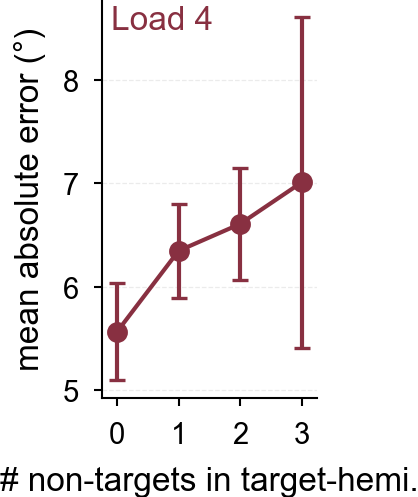

In [18]:
precision = []

f, ax = plt.subplots(figsize=(1.25,1.9))

df_helper = df.loc[df.SetSize == 4]
for hemiload in np.unique(df_helper.hemiload):
    preci = []
    for subj in df_helper.Subject.unique():
        df_subj = df_helper.loc[
            (df_helper.hemiload == hemiload) &
            (df_helper.Subject == subj)
        ]
        if len(df_subj) > 10:
            preci.append(np.nanmean(np.abs(df_subj.error_deg)))
        else:
            preci.append(np.nan)
    precision.append(preci)

means = np.nanmean(precision, axis=1)
errors = sem(precision, axis=1, nan_policy='omit')
ax.errorbar(
    np.unique(df_helper.hemiload),
    means,
    yerr=errors,
    color=colors['Load4'],
    marker='o',
    markersize=4,
    linewidth=1.0,
    capsize=2,
    capthick=0.8
)

ax.text(-0.1, 8.5,'Load 4', color=colors['Load4'])
ax.set_xlabel('# non-targets in target-hemi.')
ax.set_ylabel('mean absolute error (°)')
ax.set_xlim(-0.25, 3.25)
ax.set_xticks([0,1,2,3])
ax.grid(axis='y', alpha=0.25, linewidth=0.3)
plt.tight_layout()
#plt.savefig(PATH + 'HemiloadPrecision.svg', dpi=300)

### model the BFA

In [19]:
df['abs_error_deg'] = np.abs(df.error_deg)
df_helper = df.loc[df.SetSize==4]

M = smf.mixedlm('abs_error_deg ~ hemiload', data=df_helper, groups=df_helper['Subject']).fit(method='lbfgs')
M.summary()

# reporting summary
beta = M.params['hemiload']
se   = M.bse['hemiload']
tval = M.tvalues['hemiload']
pval = M.pvalues['hemiload']
ci_low, ci_high = M.conf_int().loc['hemiload']
N = int(M.nobs)
print(r'$\beta$ = '+str(np.round(beta,2))+' °/item, 95% CI ['+\
      str(np.round(ci_low,2))+', '+str(np.round(ci_high,2))+'], t('+\
      str(int(M.df_resid))+') = '+str(np.round(tval,2))+\
      ', p = '+str("{:.2e}".format(pval))+\
      ', N = '+str(len(df))+' trials across '+str(len(df.Subject.unique()))+' subjects')

$\beta$ = 0.58 °/item, 95% CI [0.18, 0.99], t(2056) = 2.83, p = 4.70e-03, N = 4942 trials across 18 subjects


/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the e

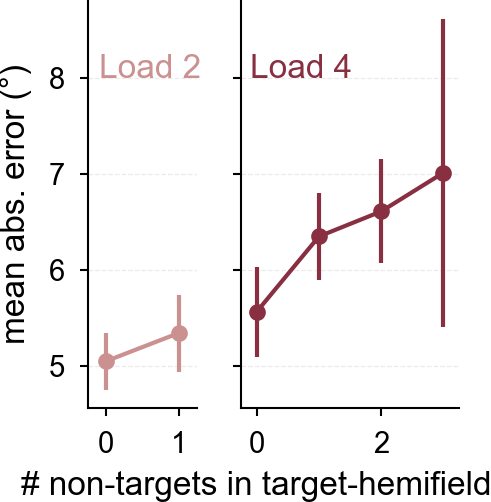

In [20]:
precision = {l: [] for l in df.SetSize.unique()}

f, ax = plt.subplots(1,2,figsize=(1.77,1.77), sharey=True, gridspec_kw={'width_ratios': [0.5,1]})

colorsL = ['lightsalmon',  'darkred']
for l, load in enumerate([2,4]):#enumerate(df.SetSize.unique()):
    df_load = df.loc[(df.SetSize==load)]
    for h, hemiload in enumerate(np.unique(df_load.hemiload)):
        preci = []
        for subj in df_load.Subject.unique():
            df_subj = df_load.loc[(df_load.hemiload==hemiload) & (df_load.Subject == subj)]#.loc[(df.SetSize==4)]
            # unilateral
            if len(df_subj) > 10:
                preci.append(np.nanmean(np.abs(df_subj.error_deg)))
            else:
                preci.append(np.nan)
        precision[load].append(preci)
            
    ax[l].errorbar(np.unique(df_load.hemiload),\
                   np.nanmean(precision[load], axis=1),\
                yerr = sem(precision[load], nan_policy='omit', axis=1), color = colors['Load'+str(load)],\
                 marker='o')

#nicer ticks
f.text(0.55, 0, '# non-targets in target-hemifield', ha='center')
for a in ax:
    a.grid(axis='y', alpha=0.25, linewidth=0.3)
ax[0].set_xlim([-0.25, 1.25])
ax[0].text(-0.1, 8,'Load 2', color=colors['Load2'])
ax[1].set_xlim([-0.25, 3.25])
ax[1].text(-0.1, 8,'Load 4', color=colors['Load4'])
ax[0].set_ylabel('mean abs. error (°)')
plt.tight_layout()
#plt.savefig(PATH+'LoadPrecision.svg', dpi=300)


# Attraction to closest attractor within vs across hemifields

# attraction to closest distractor (within, across, split)

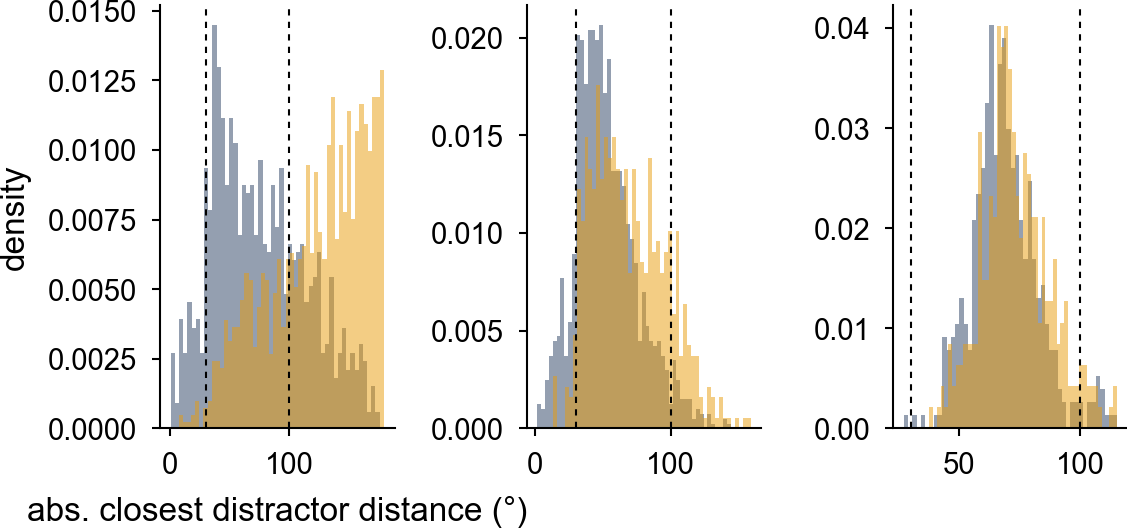

In [22]:
f, ax = plt.subplots(1,3,figsize=(4,2))
defined_range = [30, 100]
for lidx, load in enumerate(np.unique(df.SetSize)):
    
    df_withinAll = df.loc[(df.withinAcross == True) & (df.SetSize==load)]
    df_acrossAll = df.loc[(df.withinAcross == False) & (df.SetSize==load)]


    ax[lidx].axvline(defined_range[0], color='k', dashes=[3,3], lw=0.5)
    ax[lidx].axvline(defined_range[1], color='k', dashes=[3,3], lw=0.5)
    ax[lidx].hist(np.rad2deg(np.abs(df_withinAll['rel_loc'].values)), density=True, bins=50, alpha=0.5, color=colors['Within']);
    ax[lidx].hist(np.rad2deg(np.abs(df_acrossAll['rel_loc'].values)), density=True, bins=50, alpha=0.5, color=colors['Across']);
ax[0].set_ylabel('density')
ax[0].set_xlabel('abs. closest distractor distance (°)')
plt.tight_layout()

/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/ipykernel_launcher.py:96: RuntimeWarning: Mean of empty slice
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/ipykernel_launcher.py:96: RuntimeWarning: Mean of empty slice
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anacond

/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/ipykernel_launcher.py:96: RuntimeWarning: Mean of empty slice
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_sca

/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/ipykernel_launcher.py:96: RuntimeWarning: Mean of empty slice
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_sca

/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/ipykernel_launcher.py:96: RuntimeWarning: Mean of empty slice
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/ipykernel_launcher.py:96: RuntimeWarning: Mean of empty slice
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anacond

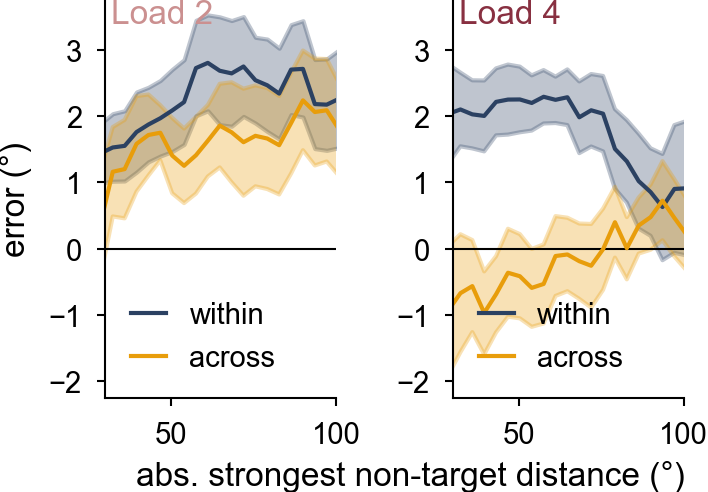

In [23]:
import statsmodels.formula.api as smf

df['aboveCapacity'] = df.SetSize > 2


folded=True
movavgWithin, movavgAcross = {l: [] for l in np.unique(df.SetSize)}, {l: [] for l in np.unique(df.SetSize)}
fit_within,fit_across = {l: [] for l in np.unique(df.SetSize)}, {l: [] for l in np.unique(df.SetSize)}
fit_all = {l: [] for l in np.unique(df.SetSize)}
fit_freeW, fit_freeA = {l: [] for l in np.unique(df.SetSize)}, {l: [] for l in np.unique(df.SetSize)}
for lidx, load in enumerate(np.unique(df.SetSize)):
    df_helper = df.loc[(df.SetSize==load)]
    for subj in df.Subject.unique():
        df_subj = df_helper.loc[df_helper.Subject==subj].copy()
        
        if len(df_subj) > 20:
            df_within = df_subj.loc[df_subj.hemi == df_subj.hemiD].copy()
            df_across = df_subj.loc[df_subj.hemi != df_subj.hemiD].copy()

            xx, m_err, std_err = mov_avg(df_within['rel_loc'].values, df_within['error'].values, w1, w2, folded)
            movavgWithin[load].append(m_err)

            xx, m_err, std_err = mov_avg(df_across['rel_loc'].values, df_across['error'].values, w1, w2, folded)
            movavgAcross[load].append(m_err)
            
            # model fit
            M = smf.ols('error~DoG', data=df_within).fit()
            fit_within[load].append(np.rad2deg(M.params['DoG']))
            
            M = smf.ols('error~DoG', data=df_across).fit()
            fit_across[load].append(np.rad2deg(M.params['DoG']))
            
            M = smf.ols('error~DoG', data=df_subj).fit()
            fit_all[load].append(np.rad2deg(M.params['DoG']))
            
            # model-free fit
            df_rangeW = df_within.loc[(np.abs(df_within.rel_loc)>np.deg2rad(defined_range[0])) &\
                             (np.abs(df_within.rel_loc)<np.deg2rad(defined_range[1]))]
            fit_freeW[load].append(np.rad2deg(np.nanmean((df_rangeW['error']*np.sign(df_rangeW['rel_loc'])))))
            
            df_rangeA = df_across.loc[(np.abs(df_across.rel_loc)>np.deg2rad(defined_range[0])) &\
                             (np.abs(df_across.rel_loc)<np.deg2rad(defined_range[1]))]
            fit_freeA[load].append(np.rad2deg(np.nanmean((df_rangeA['error']*np.sign(df_rangeA['rel_loc'])))))
            

f, ax = plt.subplots(1,2,figsize=(2.6,1.74), sharey=False)
for lidx, load in enumerate(np.unique(df.SetSize)[:-1]):
    ax[lidx].axhline(0, color='k', lw=0.5)
    ax[lidx].axvline(0, color='k', lw=0.5)
    
    mean, CI = np.rad2deg(np.nanmean(movavgWithin[load], axis=0)), np.rad2deg(sem(movavgWithin[load], axis=0, nan_policy='omit'))
    ax[lidx].plot(np.rad2deg(xx), mean, color=colors['Within'], label='within')
    ax[lidx].fill_between(np.rad2deg(xx), mean - CI, mean + CI, alpha=0.3, color=colors['Within'])
    
    mean, CI = np.rad2deg(np.nanmean(movavgAcross[load], axis=0)), np.rad2deg(sem(movavgAcross[load], axis=0, nan_policy='omit'))
    ax[lidx].plot(np.rad2deg(xx), mean, color=colors['Across'], label='across')
    ax[lidx].fill_between(np.rad2deg(xx), mean - CI, mean + CI, alpha=0.3, color=colors['Across'])
    
    ax[lidx].set_xlim([defined_range[0], defined_range[1]])
    ax[lidx].legend(handlelength=1.2, loc=3)
    #ax[0].set_ylim([-2.5, 4.5])
ax[0].set_ylabel('error (°)')
ax[0].text(32, 3.4, 'Load 2', color=colors['Load2'])
ax[0].set_ylim([-2.25, 3.75])
ax[1].set_ylim([-2.25, 3.75])
ax[1].text(32, 3.4, 'Load 4', color=colors['Load4'])
f.text(0.22, 0, 'abs. strongest non-target distance (°)')
plt.tight_layout()
#plt.savefig(PATH+'DistractorAttraction_full.svg', dpi=300)


Within-Across Load difference, <function ttest_rel at 0x79991702e488>: t(17) = -2.87, p = 1.07e-02, mean = -1.69, 95% CI [-2.94,-0.45]
Within-Across Load-2, <function ttest_rel at 0x79991702e488>: t(17) = 1.82, p = 8.62e-02, mean = 0.98, 95% CI [-0.15,2.1]
Within-Across Load-4, <function ttest_rel at 0x79991702e488>: t(17) = 4.04, p = 8.48e-04, mean = 2.67, 95% CI [1.27,4.06]


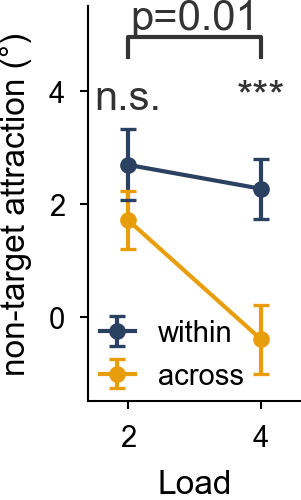

In [30]:
from scipy.stats import ttest_ind, ttest_rel
f, ax = plt.subplots(figsize=(1.3,1.9))
colorsC = ['lightsalmon', 'darkred']

ax.errorbar([2,4],\
             [np.mean(fit_within[2]), np.mean(fit_within[4])],\
             yerr = [sem(fit_within[2]), sem(fit_within[4])],\
             label='within', marker='o', color=colors['Within'], capsize=2,
    capthick=0.8)
ax.errorbar([2,4],\
             [np.mean(fit_across[2]), np.mean(fit_across[4])],\
             yerr = [sem(fit_across[2]), sem(fit_across[4])],\
             label='across', marker='o', color=colors['Across'], capsize=2,
    capthick=0.8)
ax.set_ylabel('non-target attraction (°)')
ax.legend(loc=(0,0), handlelength=1.2)
ax.set_xlabel('Load')

# p-values
y0, y1 = ax.get_ylim()
stats_w = ['***' if ttest_rel(fit_within[2], fit_across[2])[1] < 0.005\
           else '**' if ttest_rel(fit_within[2], fit_across[2])[1] < 0.01\
            else '*' if ttest_rel(fit_within[2], fit_across[2])[1] < 0.05 else 'n.s.'][0]
stats_a = ['***' if ttest_rel(fit_within[4], fit_across[4])[1] < 0.005\
           else '**' if ttest_rel(fit_within[4], fit_across[4])[1] < 0.01\
            else '*' if ttest_rel(fit_within[4], fit_across[4])[1] < 0.05 else 'n.s.'][0]
p_interact = np.round(ttest_rel(fit_within[2]-np.array(fit_across[2]),\
                       fit_within[4]-np.array(fit_across[4]))[1], 2)
ax.annotate(stats_w,(2, y1), ha='center', va='bottom', fontsize=10,  color='#333333')
ax.annotate(stats_a,(4, y1), ha='center', va='bottom', fontsize=10,  color='#333333')
ax.plot([2,2,4,4],\
        [y1+3*y1/10,y1+4*y1/10, y1+4*y1/10, y1+3*y1/10], linewidth=1, color='#333333')
ax.annotate('p='+str(p_interact),\
           (3, y1+4*y1/10), ha='center', va='bottom', fontsize=10, color='#333333')
ax.set_xlim([1.4, 4.6])
ax.set_ylim([-1.5, 5.5])
plt.tight_layout()
#plt.savefig(PATH+'NontargetAttractionWA_stats.svg', dpi=300)

# print significances
print_stats(a=fit_within[2]-np.array(fit_across[2]),\
            b=fit_within[4]-np.array(fit_across[4]), ttest=ttest_rel, text='Within-Across Load difference')

print_stats(a=fit_within[2],\
            b=fit_across[2], ttest=ttest_rel, text='Within-Across Load-2')
print_stats(a=fit_within[4],\
            b=fit_across[4], ttest=ttest_rel, text='Within-Across Load-4')



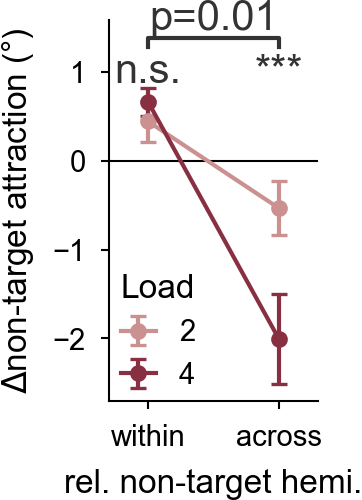

In [90]:
from scipy.stats import ttest_ind, ttest_rel
f, ax = plt.subplots(figsize=(1.3,1.9))
ax.axhline(0, color='k', lw=0.5)
colorsC = ['lightsalmon', 'darkred']

for lidx, load in enumerate(np.unique(df.SetSize)[:-1]):
    ax.errorbar([0, 1],\
                 [np.mean(fit_within[load]-np.array(fit_all[load])), np.mean(fit_across[load]-np.array(fit_all[load]))],\
                 yerr = [sem(fit_within[load]-np.array(fit_all[load])), sem(fit_across[load]-np.array(fit_all[load]))],\
                 label=load, marker='o', color=colors['Load'+str(load)], capsize=2,
        capthick=0.8)
ax.set_ylabel('$\Delta$non-target attraction (°)')
ax.legend(loc=(0,0), title='Load', handlelength=1.2)
ax.set_xticks([0,1])
ax.set_xlim([-0.3, 1.3])
ax.set_xticklabels(['within', 'across'])
ax.set_xlabel('rel. non-target hemi.')

# p-values
y0, y1 = ax.get_ylim()
stats_w = ['***' if ttest_rel(fit_within[2], fit_within[4])[1] < 0.005\
           else '**' if ttest_rel(fit_within[2], fit_within[4])[1] < 0.01\
            else '*' if ttest_rel(fit_within[2], fit_within[4])[1] < 0.05 else 'n.s.'][0]
stats_a = ['***' if ttest_rel(fit_across[2], fit_across[4])[1] < 0.005\
           else '**' if ttest_rel(fit_across[2], fit_across[4])[1] < 0.01\
            else '*' if ttest_rel(fit_across[2], fit_across[4])[1] < 0.05 else 'n.s.'][0]
p_interact = np.round(ttest_rel(fit_within[2]-np.array(fit_across[2]),\
                       fit_within[4]-np.array(fit_across[4]))[1], 2)
ax.annotate(stats_w,(0, y1-0.2), ha='center', va='bottom', fontsize=10,  color='#333333')
ax.annotate(stats_a,(1, y1-0.2), ha='center', va='bottom', fontsize=10,  color='#333333')
ax.plot([0,0,1,1],\
        [y1+3*y1/10,y1+4*y1/10, y1+4*y1/10, y1+3*y1/10], linewidth=1, color='#333333')
ax.annotate('p='+str(p_interact),\
           (0.5, y1+4*y1/10), ha='center', va='bottom', fontsize=10, color='#333333')

plt.tight_layout()
#plt.savefig(PATH+'NontargetAttraction_stats.svg', dpi=300)

# f, ax = plt.subplots(figsize=(1.2,1.68))
# diff2 = fit_within[2]-np.array(fit_across[2])
# diff4 = fit_within[4]-np.array(fit_across[4])
# ax.axhline(0, color='k', lw=0.5)
# ax.errorbar([2, 4, 8], [np.mean(diff2), np.mean(diff4), np.mean(diff8)],\
#              yerr = [sem(diff2),sem(diff4),sem(diff8)],marker='o', color='k')
# ax.set_ylabel('$\Delta$distractibility')
# ax.set_xticks([2,4,8])
# ax.set_xlabel('load')
# plt.tight_layout()
#plt.savefig(PATH+'DistractorAttractionWA_stats.svg', dpi=300)

